In [179]:
import numpy as np
import pandas as pd
from cdc_ml.config import PREFERENCE_PROCESSED,POLLS_PROCESSED,RECORDS_PROCESSED
from cdc_ml.datasets.constants import TIMEZONE
import matplotlib.pyplot as plt
import seaborn as sns


In [180]:
df = pd.read_parquet(PREFERENCE_PROCESSED)
df_poll = pd.read_parquet(POLLS_PROCESSED)
df_records = pd.read_parquet(RECORDS_PROCESSED)

In [181]:
df.head()

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040
0,0,ajithak,1,Tuesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,0,0,0,0,0,1,1
1,0,ajithak,2,Wednesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,0,0,0,0,0,1,1
2,0,ajithak,3,Thursday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,0,0,0,0,0,1,1
3,0,ajithak,4,Friday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,0,0,0,0,0,1,1
4,0,ajithak,5,Saturday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,0,0,0,0,0,1,1


In [182]:
cycle_booking_count = df_poll.groupby(["id"])["has_booking"].sum().reset_index(name="booking_total")
print(cycle_booking_count)

      id  booking_total
0      0              1
1      1              2
2      2              1
3      3              0
4      4              6
..   ...            ...
117  117              0
118  118              2
119  119              3
120  120              1
121  121              2

[122 rows x 2 columns]


In [183]:
df = df.merge(cycle_booking_count,on="id",how='left')

In [184]:
df.head(5)

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040,booking_total
0,0,ajithak,1,Tuesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,0,0,0,0,0,1,1,1
1,0,ajithak,2,Wednesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,0,0,0,0,0,1,1,1
2,0,ajithak,3,Thursday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,0,0,0,0,0,1,1,1
3,0,ajithak,4,Friday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,0,0,0,0,0,1,1,1
4,0,ajithak,5,Saturday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,0,0,0,0,0,1,1,1


In [185]:
df_melt = df.melt(id_vars=["id","username","day_of_week","pref_start","pref_end","date","booking_total"],
                    value_vars=["t_0830","t_1020","t_1245","t_1435","t_1625","t_1850","t_2040"],
                    var_name="timeslot",
                    value_name="selected"


                  )

In [186]:
df_melt.head()

,id,username,day_of_week,pref_start,pref_end,date,booking_total,timeslot,selected
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,1,t_0830,0
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,1,t_0830,0
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,1,t_0830,0
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,1,t_0830,0
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,1,t_0830,0


In [187]:
selected_total = df_melt.groupby(["id","day_of_week","timeslot"])["selected"].sum().reset_index(name="total_selected")
selected_total = selected_total.loc[selected_total["total_selected"]!=0]
per_id = (selected_total.groupby("id").size()
          .reset_index(name="n_cells")
          .assign(coverage=lambda d: d["n_cells"] / 49)
          .sort_values("n_cells", ascending=False))
print(per_id)

    id  n_cells  coverage
17  17       49  1.000000
14  14       49  1.000000
9    9       49  1.000000
8    8       49  1.000000
38  39       49  1.000000
..  ..      ...       ...
81  82        3  0.061224
46  47        2  0.040816
23  23        2  0.040816
75  76        2  0.040816
72  73        2  0.040816

[120 rows x 3 columns]


In [188]:
cycle_booking=df_poll.groupby(["id"])["has_booking"].sum().reset_index(name="booking_count")
per_id = per_id.merge(cycle_booking,on=["id"],how="left")
print(per_id)

     id  n_cells  coverage  booking_count
0    17       49  1.000000              5
1    14       49  1.000000              7
2     9       49  1.000000              2
3     8       49  1.000000              1
4    39       49  1.000000              1
..   ..      ...       ...            ...
115  82        3  0.061224              0
116  47        2  0.040816              1
117  23        2  0.040816              0
118  76        2  0.040816              0
119  73        2  0.040816              1

[120 rows x 4 columns]


In [189]:
from scipy.stats import pearsonr,spearmanr

r,p = pearsonr(per_id["coverage"],per_id["booking_count"])
print(r,r**2,p)


r,p = spearmanr(per_id["coverage"],per_id["booking_count"])
print(r,r**2,p)

0.28795228214809376 0.0829165167942954 0.0014268042916770398
0.31874135176965884 0.1015960493279494 0.00038802145323469067


In [190]:
df_records.head()

,id,username,lesson_at,booking_at,booking_type,class_type,is_one_team
0,0,ajithak,2025-08-28 18:50:00+08:00,2025-08-21 09:24:06.300383+08:00,0,3,0
1,1,ajithak,2025-08-28 20:40:00+08:00,2025-08-21 09:24:16.048708+08:00,0,3,0
2,2,addity,2025-09-21 14:35:00+08:00,2025-08-23 00:57:26.576198+08:00,0,3a,1
3,3,bryan,2025-08-28 20:40:00+08:00,2025-08-25 12:06:06.539664+08:00,0,3a,0
4,4,bryan,2025-08-31 12:45:00+08:00,2025-08-26 12:50:24.317931+08:00,0,3a,0


In [191]:

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(df, x, y):
    ct = pd.crosstab(df[x], df[y])
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1                       # df_min — drives the thresholds
    v = np.sqrt(chi2 / (n * k))

    small, medium, large = (c / np.sqrt(k) for c in (0.10, 0.30, 0.50))
    if   v >= large:  label = "large"
    elif v >= medium: label = "medium"
    elif v >= small:  label = "small"
    else:             label = "negligible / no association"

    print(f"χ²={chi2:.1f}  p={p:.2e}  V={v:.3f}  (df={k})  → {label}")
    return v, p


In [192]:
df_poll = df_poll.merge(df_records[["username","is_one_team","class_type"]],on="username",)
print(df_poll.head())

   id username               cycle_start                 cycle_end  \
0   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
1   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
2   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
3   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   
4   0  ajithak 2025-08-19 09:15:00+08:00 2025-08-21 11:00:00+08:00   

                 polling_at  has_booking  cycle_start_month  cycle_start_day  \
0 2025-08-19 09:00:00+08:00        False                  8               19   
1 2025-08-19 09:00:00+08:00        False                  8               19   
2 2025-08-19 10:00:00+08:00        False                  8               19   
3 2025-08-19 10:00:00+08:00        False                  8               19   
4 2025-08-19 11:00:00+08:00        False                  8               19   

   cycle_start_dow  cycle_start_hour  polling_month  polling_day  polling_dow  \
0                

In [193]:
per_user = df_poll.groupby("username").agg(
    rate=("has_booking", "mean"),
    is_one_team=("is_one_team", "first"),
)
per_user.groupby("is_one_team")["rate"].agg(["mean", "median", "count"])

,mean,median,count
is_one_team,,,
0,0.015448,0.012827,26
1,0.010753,0.011414,11


In [194]:

per_user = df_poll.groupby("username").agg(
    rate=("has_booking", "mean"),
    class_type=("class_type", "first"),
)
per_user.groupby("class_type")["rate"].agg(["mean", "median", "count"])

,mean,median,count
class_type,,,
3,0.012758,0.010406,12
3a,0.014673,0.013048,25


In [195]:
df.head()

,id,username,day_of_week,day_name,pref_start,pref_end,date,t_0830,t_1020,t_1245,t_1435,t_1625,t_1850,t_2040,booking_total
0,0,ajithak,1,Tuesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,0,0,0,0,0,1,1,1
1,0,ajithak,2,Wednesday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,0,0,0,0,0,1,1,1
2,0,ajithak,3,Thursday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,0,0,0,0,0,1,1,1
3,0,ajithak,4,Friday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,0,0,0,0,0,1,1,1
4,0,ajithak,5,Saturday,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,0,0,0,0,0,1,1,1


In [196]:
df_melt.groupby(["id","timeslot"])["booking_total"].first().reset_index()

,id,timeslot,booking_total
0,0,t_0830,1
1,0,t_1020,1
2,0,t_1245,1
3,0,t_1435,1
4,0,t_1625,1
...,...,...,...
835,121,t_1245,2
836,121,t_1435,2
837,121,t_1625,2
838,121,t_1850,2


In [197]:
seg_dic = {"t_0830":"morning","t_1020":"morning","t_1245":"noon","t_1435":"noon","t_1625":"noon","t_1850":"noon","t_2040":"night"}
df_melt = df_melt.assign(seg=lambda x: x["timeslot"].map(seg_dic))
print(df_melt.head())

   id username  day_of_week                pref_start  \
0   0  ajithak            1 2025-08-19 00:00:00+08:00   
1   0  ajithak            2 2025-08-19 00:00:00+08:00   
2   0  ajithak            3 2025-08-19 00:00:00+08:00   
3   0  ajithak            4 2025-08-19 00:00:00+08:00   
4   0  ajithak            5 2025-08-19 00:00:00+08:00   

                   pref_end                      date  booking_total timeslot  \
0 2025-08-31 00:00:00+08:00 2025-08-19 00:00:00+08:00              1   t_0830   
1 2025-08-31 00:00:00+08:00 2025-08-20 00:00:00+08:00              1   t_0830   
2 2025-08-31 00:00:00+08:00 2025-08-21 00:00:00+08:00              1   t_0830   
3 2025-08-31 00:00:00+08:00 2025-08-22 00:00:00+08:00              1   t_0830   
4 2025-08-31 00:00:00+08:00 2025-08-23 00:00:00+08:00              1   t_0830   

   selected      seg  
0         0  morning  
1         0  morning  
2         0  morning  
3         0  morning  
4         0  morning  


In [198]:
df_melt["booking_total"].value_counts()

booking_total
2     4361
1     4172
0     2086
4     1687
5     1141
3     1022
6      868
7      427
19     399
27     308
8      266
24     210
25     210
21     210
13     147
12      77
9       28
Name: count, dtype: int64

In [199]:
df_melt = df_melt.assign(
        count=df_melt.groupby("id")["id"].transform("count"),
        selected_sum=df_melt.groupby(["id","timeslot"])["selected"].transform("sum")
    ).assign(selected_share=lambda x: x["selected_sum"] / x["count"])


In [200]:
sel = df_melt[df_melt.selected == 1]
most_booking_day = {0,1,3,4}

per_user = sel.groupby("id").agg(
    n_selected    = ("timeslot", "size"),          # breadth: how many slots
    booking_total = ("booking_total", "first"),
)
print(per_user)
per_user["evening_share"] = (
    sel.assign(is_most_booking_day=sel.day_of_week.isin(most_booking_day))
       .groupby("id")["is_most_booking_day"].mean()
)
print(per_user)

print(per_user[["n_selected", "evening_share", "booking_total"]].corr("spearman"))

     n_selected  booking_total
id                            
0            36              1
1            91              2
2           168              1
3           188              0
4            74              6
..          ...            ...
117         210              0
118          70              2
119         111              3
120         132              1
121         210              2

[120 rows x 2 columns]
     n_selected  booking_total  evening_share
id                                           
0            36              1       0.388889
1            91              2       0.307692
2           168              1       0.333333
3           188              0       0.452128
4            74              6       0.256757
..          ...            ...            ...
117         210              0       0.566667
118          70              2       0.600000
119         111              3       0.540541
120         132              1       0.575758
121         210      

In [201]:
df_records = df_records.dropna(subset=["lesson_at"])

In [202]:
df_records.info()

<class 'pandas.DataFrame'>
Index: 310 entries, 0 to 498
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype                         
---  ------        --------------  -----                         
 0   id            310 non-null    int64                         
 1   username      310 non-null    str                           
 2   lesson_at     310 non-null    datetime64[ns, Asia/Singapore]
 3   booking_at    310 non-null    datetime64[ns, Asia/Singapore]
 4   booking_type  310 non-null    int64                         
 5   class_type    310 non-null    str                           
 6   is_one_team   310 non-null    int64                         
dtypes: datetime64[ns, Asia/Singapore](2), int64(3), str(2)
memory usage: 21.2 KB


In [203]:
df_records.head()

,id,username,lesson_at,booking_at,booking_type,class_type,is_one_team
0,0,ajithak,2025-08-28 18:50:00+08:00,2025-08-21 09:24:06.300383+08:00,0,3,0
1,1,ajithak,2025-08-28 20:40:00+08:00,2025-08-21 09:24:16.048708+08:00,0,3,0
2,2,addity,2025-09-21 14:35:00+08:00,2025-08-23 00:57:26.576198+08:00,0,3a,1
3,3,bryan,2025-08-28 20:40:00+08:00,2025-08-25 12:06:06.539664+08:00,0,3a,0
4,4,bryan,2025-08-31 12:45:00+08:00,2025-08-26 12:50:24.317931+08:00,0,3a,0


      id  day_of_week  n
0      0            0  1
1      0            1  2
2      0            2  2
3      0            3  2
4      0            4  2
..   ...          ... ..
637  121            2  8
638  121            3  9
639  121            4  9
640  121            5  9
641  121            6  9

[642 rows x 3 columns]


<Axes: xlabel='day_of_week', ylabel='frac'>

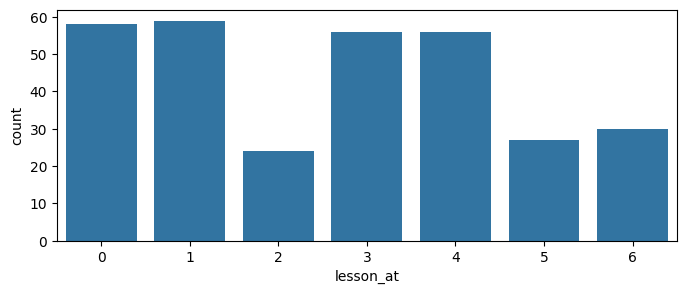

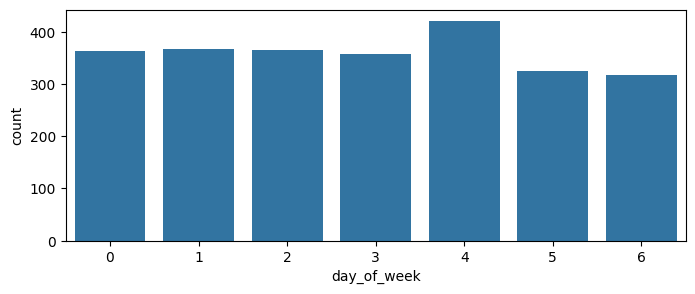

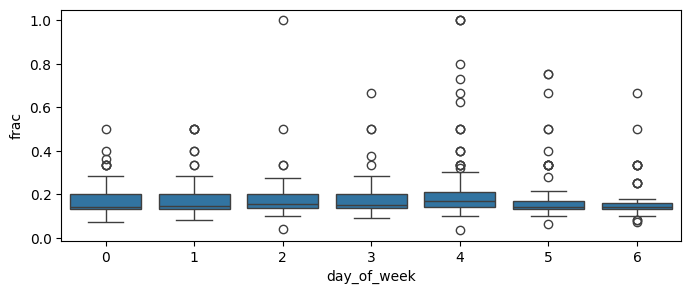

In [204]:

lesson_booked_dow = df_records["lesson_at"].dt.day_of_week.value_counts().sort_index().reset_index()
fig,ax = plt.subplots(figsize=(8,3))
sns.barplot(data=lesson_booked_dow,x="lesson_at",y="count")

#day_pref = df_melt.drop_duplicates(["id","day_of_week"]).loc[df_melt["selected"]==1]
day_pref = df["day_of_week"].value_counts().reset_index(name="count")
# print(day_pref)

fig,ax = plt.subplots(figsize=(8,3))
sns.barplot(data=day_pref,x="day_of_week",y="count")


# each customer's shape: fraction of their prefs on each day
shape = df.groupby(["id", "day_of_week"]).size().reset_index(name="n")
print(shape)
shape["frac"] = shape["n"] / shape.groupby("id")["n"].transform("sum")

fig,ax = plt.subplots(figsize=(8,3))
# the test: spread of that fraction ACROSS customers, per day
sns.boxplot(data=shape, x="day_of_week", y="frac")



In [205]:
df.loc[df["day_of_week"]==3][["username"]].value_counts()

username
jun         33
mya         26
srpr        23
addity      22
anmol       22
jy          21
carol       19
matt        17
apple       17
nur         17
gohguan     16
anaya       14
ali         14
tomato      12
poopie      10
d            9
flower       8
joy          7
np           6
aswath       6
max          5
ryan         5
bhara        5
bryan        4
ranjith      4
fir          4
ajithak      2
isyaf        2
natar        2
phuc         2
sara         1
bw           1
kim          1
Name: count, dtype: int64

  timeslot  count
0   t_0830     59
1   t_1020     62
2   t_1245     73
3   t_1435     73
4   t_1625     61
5   t_1850     76
6   t_2040     78


<Axes: xlabel='timeslot', ylabel='count'>

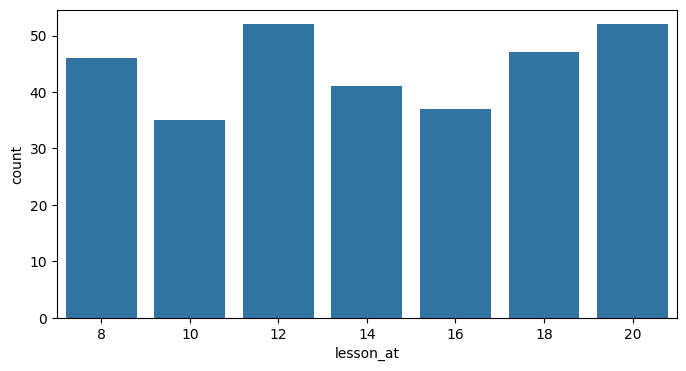

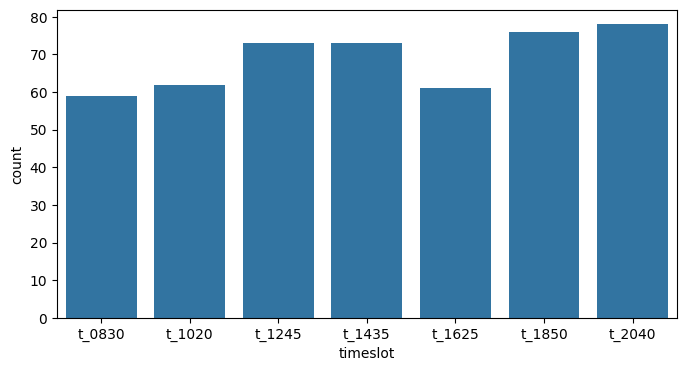

In [206]:
lesson_booked_dow = df_records["lesson_at"].dt.hour.value_counts().sort_index().reset_index()
fig,ax = plt.subplots(figsize=(8,4))
sns.barplot(data=lesson_booked_dow,x="lesson_at",y="count")

timeslot_pref = df_melt.drop_duplicates(["id","timeslot"]).loc[df_melt["selected"]==1]

timeslot_pref = timeslot_pref.groupby("timeslot")["username"].count().reset_index(name="count")
print(timeslot_pref)
fig,ax = plt.subplots(figsize=(8,4))
sns.barplot(data=timeslot_pref,x="timeslot",y="count")


In [207]:
df_melt.head()

,id,username,day_of_week,pref_start,pref_end,date,booking_total,timeslot,selected,seg,count,selected_sum,selected_share
0,0,ajithak,1,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-19 00:00:00+08:00,1,t_0830,0,morning,91,2,0.021978
1,0,ajithak,2,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-20 00:00:00+08:00,1,t_0830,0,morning,91,2,0.021978
2,0,ajithak,3,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-21 00:00:00+08:00,1,t_0830,0,morning,91,2,0.021978
3,0,ajithak,4,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-22 00:00:00+08:00,1,t_0830,0,morning,91,2,0.021978
4,0,ajithak,5,2025-08-19 00:00:00+08:00,2025-08-31 00:00:00+08:00,2025-08-23 00:00:00+08:00,1,t_0830,0,morning,91,2,0.021978


In [212]:
sel = df_melt.loc[df_melt["selected"] == 1, ["timeslot", "id"]]
print(sel)

# how many slots does each id select?
print(sel.groupby("id")["timeslot"].nunique().value_counts())

      timeslot   id
5       t_0830    0
12      t_0830    0
15      t_0830    1
19      t_0830    1
23      t_0830    1
...        ...  ...
17614   t_2040  121
17615   t_2040  121
17616   t_2040  121
17617   t_2040  121
17618   t_2040  121

[10693 rows x 2 columns]
timeslot
7    56
2    19
4    16
3     9
5     8
1     8
6     4
Name: count, dtype: int64


In [213]:
rates = (
    df_poll[["id", "has_booking"]]
    .merge(sel, on="id")                                # intentional fan-out: (id × selected slot)
    .groupby(["timeslot", "id"])["has_booking"].mean()  # per-id rate
    .groupby("timeslot").mean()                          # avg across ids in that slot
)
print(rates)

timeslot
t_0830    0.024974
t_1020    0.025884
t_1245    0.023750
t_1435    0.023698
t_1625    0.025481
t_1850    0.024801
t_2040    0.025062
Name: has_booking, dtype: float64
